# Kenbec Field Inversion - Minimal Workflow

Load Kenbec station data, plot the soundings and survey map, invert every
station with the quintic B-spline matrix method, and plot the recovered
resistivity section.

See [`6. pytem_kenbec.ipynb`](6.%20pytem_kenbec.ipynb) for the full
derivation, validation against classical waveform quadrature, and the
depth-of-investigation analysis.

In [1]:
import sys, os, time
from pathlib import Path
import concurrent.futures as _cf

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import (
    fwd_circle_offset, fwd_square_offset, read_xyz, Survey,
    setup_waveform_matrix, getJ_ana, getR,
)
from pytem.inversion import _alpha_search

try:
    import numba as _numba
except Exception:
    _numba = None

plt.rcParams['figure.dpi'] = 115

## 1. Load data

In [2]:
XYZ = r"C:\Users\pamcl\Downloads\Kenbec\kenbec_project_StationData.xyz"
tem = read_xyz(XYZ)
surv = Survey(tem)

print(f"Stations : {len(tem.data)}")
for moment in ('LM', 'HM'):
    centers = tem.gate_times[moment]['center']
    print(f"  {moment}: {len(centers)} gates  [{centers[0]:.2e} ... {centers[-1]:.2e}] s")

Stations : 38
  LM: 6 gates  [1.09e-05 ... 2.94e-05] s
  HM: 22 gates  [2.24e-05 ... 2.37e-03] s


## 2. Plot data

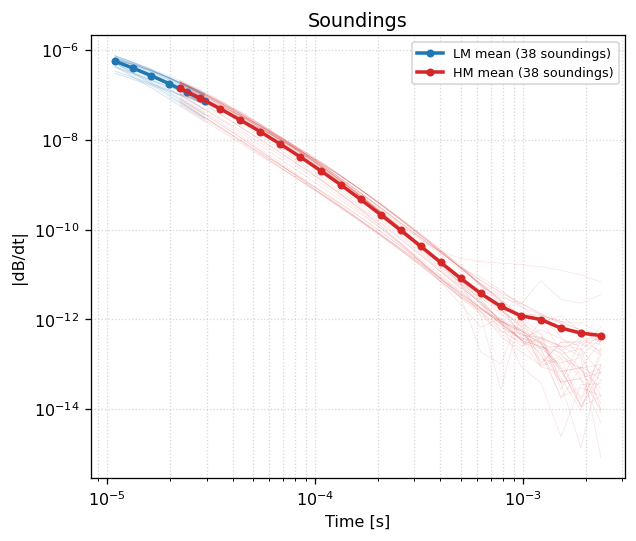

In [3]:
surv.plot_soundings()
plt.show()

## 3. Plot map

c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\contextily\tile.py:662: UserWarning: The inferred zoom level of 18 is not valid for the current tile provider (valid zooms: 0 - 17).
  warnings.warn(msg)
c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


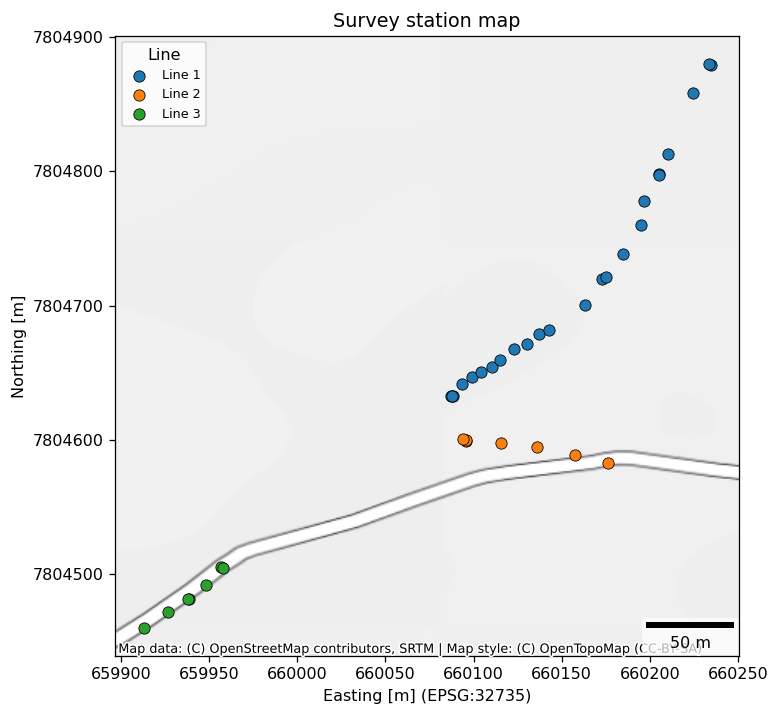

In [4]:
surv.plot_map()
plt.show()

## 4. Invert data

Every station shares the same transmitter waveform, gate timing, and loop
geometry, so the LM/HM quintic B-spline waveform matrices are built once and
reused for all stations (`pytem.setup_waveform_matrix`). Only the measured
dB/dt and the resulting Gauss-Newton fit differ from station to station.

In [5]:
# Survey / loop geometry
MOMENTS = ['LM', 'HM']
CURRENTS = {'LM': 1.0, 'HM': 10.0}
USE_SQUARE_LOOP = False   # False = equal-area circular offset loop; True = square offset loop
N_QUAD_SQUARE = 3         # square-loop quadrature order (ignored for the circular loop)

systems = {m: tem.to_pytem(m, peak_current=CURRENTS[m]) for m in MOMENTS}

tx_side = float(systems['HM']['tx_size'])
tx_radius_equal_area = float(np.sqrt(tx_side ** 2 / np.pi))
rx_x = abs(float(systems['HM']['rx_x']))
rx_y = abs(float(systems['HM']['rx_y']))
geometry_inv = 'square_offset' if USE_SQUARE_LOOP else 'circle_offset'
tx_size_inv = tx_side if USE_SQUARE_LOOP else tx_radius_equal_area

print(f"Geometry : {geometry_inv} | tx_size={tx_size_inv:.2f} m | rx=({rx_x:.2f}, {rx_y:.2f}) m")

Geometry : circle_offset | tx_size=1.69 m | rx=(13.00, 0.00) m


In [6]:
# Quintic B-spline waveform + gate matrices (built once, shared by every station)
N_STEP = 300              # step-response grid size: main speed/accuracy knob
N_DENSE_GATE = 400        # internal quadrature for the gate-averaging matrix
N_KERNEL_PER_SEGMENT = 81
PAD_DECADES = 1.0

delay_sets = []
for kw in systems.values():
    waveform_times = np.asarray(kw['waveform_times'], dtype=float)
    waveform_currents = np.asarray(kw['waveform_currents'], dtype=float)
    active = np.flatnonzero(np.diff(waveform_currents) != 0.0)
    segment_endpoints = np.unique(np.concatenate([waveform_times[active], waveform_times[active + 1]]))
    output_times = np.concatenate([kw['times'], kw['gate_open'], kw['gate_close']])
    delays = output_times[:, None] - segment_endpoints[None, :]
    delay_sets.append(delays[delays > 0.0])

positive_delays = np.concatenate(delay_sets)
shared_t_step = np.logspace(
    np.log10(positive_delays.min()) - PAD_DECADES,
    np.log10(positive_delays.max()) + PAD_DECADES,
    N_STEP)

matrix_systems = {}
for moment, kw in systems.items():
    _, apply_gate = setup_waveform_matrix(
        kw['times'], kw['waveform_times'], kw['waveform_currents'],
        gate_open=kw['gate_open'], gate_close=kw['gate_close'],
        t_step=shared_t_step, n_per_segment=N_KERNEL_PER_SEGMENT,
        n_dense_gate=N_DENSE_GATE)
    matrix_systems[moment] = {'M_gate': apply_gate.matrix}

print(f"Shared step-time grid: {shared_t_step.size} points, "
      f"[{shared_t_step[0]:.2e}, {shared_t_step[-1]:.2e}] s")

Shared step-time grid: 300 points, [4.90e-07, 4.55e-02] s


In [7]:
# Model grid and inversion settings
N_LAYERS = 15
thicknesses = np.logspace(np.log10(2.0), np.log10(25.0), N_LAYERS - 1)
depths_top = np.concatenate([[0.0], np.cumsum(thicknesses)])
rho_start = np.ones_like(depths_top) * 100.0

MAX_NOISE = 0.50          # drop gates with fractional noise above this
NOISE_FLOOR_FRAC = 0.05   # noise floor as a fraction of the signal
RHO_MIN, RHO_MAX = 0.5, 1e5
ALPHA_STEPS = 6
ALPHA_STEP = 1 / 3
MAXIT = 15
JAC_USE_NUMBA = True
JAC_USE_CUDA = False


def fwd_step_inv(thick, rho, times):
    """Step-off response (positive) for the selected offset geometry."""
    if geometry_inv == 'square_offset':
        return -fwd_square_offset(thick, rho, tx_size_inv, rx_x, rx_y, times,
                                  current=1.0, signal=-1, n_quad=N_QUAD_SQUARE,
                                  use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
                                  transform='dlf')
    return -fwd_circle_offset(thick, rho, tx_size_inv, rx_x, times,
                              current=1.0, signal=-1,
                              use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
                              transform='dlf')

In [8]:
def station_fit_systems(station):
    """Build LM + HM fit systems for one station using the shared waveform matrices."""
    fit_systems = []
    for moment in MOMENTS:
        kw = tem.to_pytem(moment, peak_current=CURRENTS[moment], station=station)
        obs = kw['obs_data']
        frac = kw['noise_std']
        noise_abs = np.maximum(frac, NOISE_FLOOR_FRAC) * obs
        good = (np.isfinite(obs) & np.isfinite(noise_abs) & (obs > 0)
                & (noise_abs > 0) & (frac <= MAX_NOISE))
        fit_systems.append({
            'M': matrix_systems[moment]['M_gate'][good],
            'obs': obs[good],
            'noise_abs': noise_abs[good],
        })
    return fit_systems


def invert_sounding(fit_systems, rho_init, maxit=MAXIT):
    """Independent alpha-search Gauss-Newton inversion for one sounding."""
    observed = np.concatenate([f['obs'] for f in fit_systems])
    noise = np.concatenate([f['noise_abs'] for f in fit_systems])
    weights = observed / noise

    def predict(log_rho):
        step = fwd_step_inv(thicknesses, np.exp(log_rho), shared_t_step)
        return np.concatenate([f['M'] @ step for f in fit_systems])

    def weighted_log_rms(pred):
        residual = np.log(observed) - np.log(np.maximum(pred, 1e-300))
        return np.sqrt(np.mean((weights * residual) ** 2)), residual

    def jacobian(log_rho, pred):
        jac_abs = getJ_ana(
            thicknesses=thicknesses, log_resistivities=log_rho, tx_size=tx_size_inv,
            times=shared_t_step, geometry=geometry_inv, rx_x=rx_x, rx_y=rx_y,
            n_quad=N_QUAD_SQUARE, use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
            transform='dlf', jacobian_mode='absolute')
        gate_jac = np.vstack([f['M'] @ jac_abs for f in fit_systems])
        result = np.zeros_like(gate_jac)
        positive = pred > 0
        result[positive] = gate_jac[positive] / pred[positive, None]
        return result

    lower, upper = np.log(RHO_MIN), np.log(RHO_MAX)
    model = np.log(np.asarray(rho_init, dtype=float).copy())
    roughness = getR(rho_init)
    pred = predict(model)
    rms, resid = weighted_log_rms(pred)
    weighted_jac = jacobian(model, pred) * weights[:, None]
    alpha = float(np.linalg.norm(weighted_jac.T @ (weights * resid), np.inf) + 1e-30)
    status = 'max iterations reached'

    for _ in range(maxit):
        pred = predict(model)
        rms, resid = weighted_log_rms(pred)
        if rms <= 1.0:
            status = 'converged'
            break
        weighted_jac = jacobian(model, pred) * weights[:, None]
        alpha_h, rms_h, delta_h, _ = _alpha_search(
            alpha, ALPHA_STEPS, weighted_jac, weights * resid, roughness, model,
            thicknesses, predict, observed, weights, lower, upper,
            alpha_step=ALPHA_STEP, rms_current=rms, plot=False)
        rms_arr, alpha_arr = np.asarray(rms_h), np.asarray(alpha_h)
        acceptable = np.flatnonzero(rms_arr <= 1.0)
        best = (int(acceptable[np.argmax(alpha_arr[acceptable])])
                if acceptable.size else int(np.argmin(rms_arr)))
        if rms_h[best] >= rms:
            status = 'stopped: no improving step'
            break
        model = np.clip(model + delta_h[best], lower, upper)
        alpha = alpha_h[best] * 10.0 ** ALPHA_STEP

    final_rms, _ = weighted_log_rms(predict(model))
    return np.exp(model), final_rms, status

Invert every station (parallel, one worker per station up to 8 threads).

In [9]:
N_WORKERS = min(os.cpu_count() or 4, 8)
n_stations = int(tem.data.shape[0])
station_ids = list(range(n_stations))

rho_sections = np.full((n_stations, rho_start.size), np.nan)
rms_stations = np.full(n_stations, np.nan)


def _invert_one(station):
    if _numba is not None and N_WORKERS > 1:
        try:
            _numba.set_num_threads(1)
        except Exception:
            pass
    fit_systems = station_fit_systems(station)
    n_gates = sum(f['obs'].size for f in fit_systems)
    if n_gates < rho_start.size:
        return station, None, np.nan
    rho, rms, status = invert_sounding(fit_systems, rho_start)
    return station, rho, rms


t0 = time.perf_counter()
with _cf.ThreadPoolExecutor(max_workers=min(N_WORKERS, n_stations)) as executor:
    for station, rho, rms in executor.map(_invert_one, station_ids):
        if rho is not None:
            rho_sections[station] = rho
        rms_stations[station] = rms
        print(f'station {station:02d}: RMS={rms:.3f}')
print(f'Inverted {n_stations} stations in {time.perf_counter() - t0:.1f} s.')

    Alpha = 3809.51,  RMS = 12.21
    Alpha = 3862.61,  RMS = 17.23
    Alpha = 3782.60,  RMS = 13.57
    Alpha = 3941.53,  RMS = 16.31
    Alpha = 1768.22,  RMS = 12.91
    RMS increased - stopping alpha search early.
    Alpha = 1792.87,  RMS = 18.05
    RMS increased - stopping alpha search early.
    Alpha = 1755.73,  RMS = 14.41
    RMS increased - stopping alpha search early.
    Alpha = 1829.50,  RMS = 16.99
    RMS increased - stopping alpha search early.
    Alpha = 3922.41,  RMS = 17.05
    Alpha = 3897.66,  RMS = 17.94
    Alpha = 3871.88,  RMS = 18.66
    Alpha = 3877.95,  RMS = 17.60
    Alpha = 1797.17,  RMS = 19.41
    RMS increased - stopping alpha search early.
    Alpha = 1820.62,  RMS = 17.77
    RMS increased - stopping alpha search early.
    Alpha = 1809.13,  RMS = 18.73
    RMS increased - stopping alpha search early.
    Alpha = 1799.99,  RMS = 18.52
    RMS increased - stopping alpha search early.
    Alpha = 8207.35,  RMS = 6.48
    Alpha = 8321.75,  RMS = 7.7

## 5. Show results

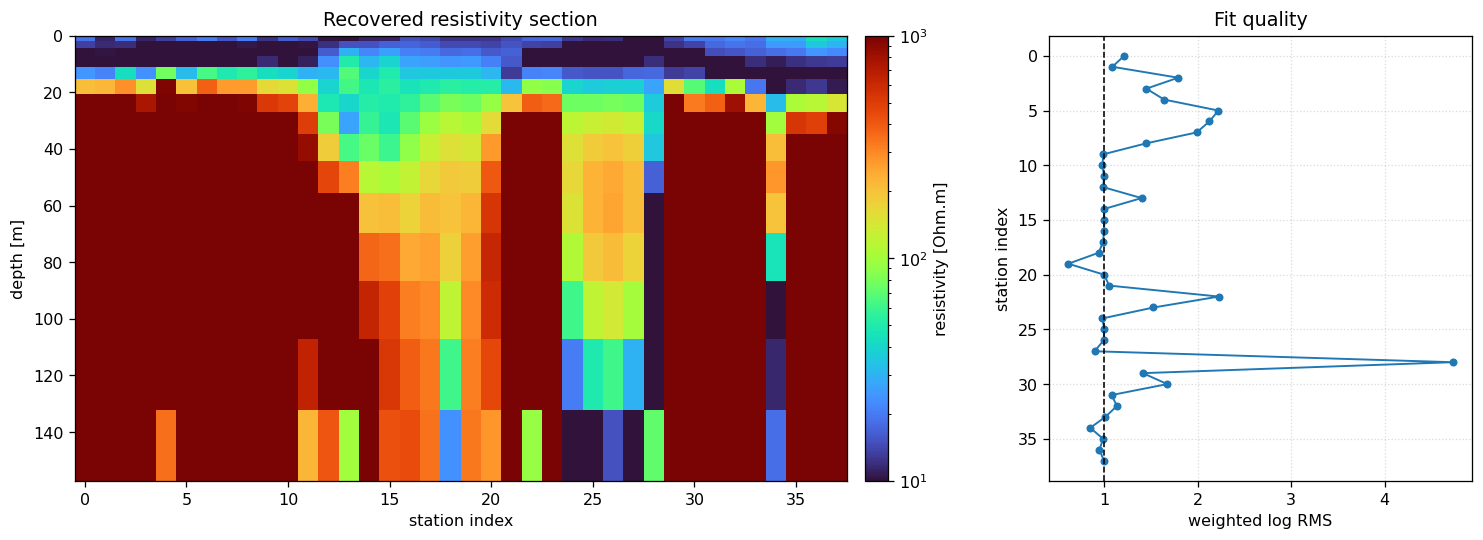

38/38 stations inverted, RMS range 0.613 to 4.729


In [10]:
valid = np.all(np.isfinite(rho_sections), axis=1) & np.isfinite(rms_stations)
station_idx = np.flatnonzero(valid)
rho_valid = rho_sections[valid]
rms_valid = rms_stations[valid]

if station_idx.size > 1:
    x_edges = np.concatenate([
        [station_idx[0] - 0.5 * (station_idx[1] - station_idx[0])],
        0.5 * (station_idx[:-1] + station_idx[1:]),
        [station_idx[-1] + 0.5 * (station_idx[-1] - station_idx[-2])]])
else:
    x_edges = np.array([station_idx[0] - 0.5, station_idx[0] + 0.5], dtype=float)
z_edges = np.concatenate([[0.0], np.cumsum(thicknesses), [np.cumsum(thicknesses)[-1] + thicknesses[-1]]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [2.2, 1.0]})

mesh = axes[0].pcolormesh(x_edges, z_edges, rho_valid.T, shading='flat',
                          cmap=plt.cm.turbo, norm=LogNorm(vmin=10, vmax=1000))
axes[0].invert_yaxis()
axes[0].set_xlabel('station index')
axes[0].set_ylabel('depth [m]')
axes[0].set_title('Recovered resistivity section')
fig.colorbar(mesh, ax=axes[0], pad=0.02, label='resistivity [Ohm.m]')

axes[1].plot(rms_valid, station_idx, 'o-', ms=4, lw=1.2)
axes[1].axvline(1.0, color='k', ls='--', lw=1)
axes[1].invert_yaxis()
axes[1].set_xlabel('weighted log RMS')
axes[1].set_ylabel('station index')
axes[1].set_title('Fit quality')
axes[1].grid(True, ls=':', alpha=0.45)

plt.tight_layout()
plt.show()

print(f'{station_idx.size}/{n_stations} stations inverted, RMS range '
      f'{np.nanmin(rms_valid):.3f} to {np.nanmax(rms_valid):.3f}')